Importing all of the needed libraries 

In [1]:
import pandas as pd
import csv
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import random
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sktime.performance_metrics.forecasting import MedianAbsolutePercentageError
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.ticker as ticker
import plotly.express as px
from sklearn.neighbors import BallTree
import numpy as np

Determine whether to use the six months prior to January as the training dataset or use the six month prior to December as the training set using a binary variable

In [2]:
end_january = 1

Loading the CRMLS data into Dataframes

In [3]:
df202506 = pd.read_csv("CRMLSSold202506.csv", encoding = "ISO-8859-1")
df202507 = pd.read_csv("CRMLSSold202507.csv", encoding = "ISO-8859-1")
df202508 = pd.read_csv("CRMLSSold202508.csv", encoding = "ISO-8859-1")
df202509 = pd.read_csv("CRMLSSold202509.csv", encoding = "ISO-8859-1")
df202510 = pd.read_csv("CRMLSSold202510.csv", encoding = "ISO-8859-1")
df202511 = pd.read_csv("CRMLSSold202511.csv", encoding = "ISO-8859-1")
df202512 = pd.read_csv("CRMLSSold202512.csv", encoding = "ISO-8859-1")
df202601 = pd.read_csv("CRMLSSold202601.csv", encoding = "ISO-8859-1")
if end_january == 1:
  training_data = pd.concat([df202507, df202508, df202509, df202510, df202511, df202512])
  testing_data = df202601.copy()
else:
  training_data = pd.concat([df202506, df202507, df202508, df202509, df202510, df202511])
  testing_data = df202512.copy()

C:\Users\jehil\AppData\Local\Temp\ipykernel_20772\641209494.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df202506 = pd.read_csv("CRMLSSold202506.csv", encoding = "ISO-8859-1")
C:\Users\jehil\AppData\Local\Temp\ipykernel_20772\641209494.py:8: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df202601 = pd.read_csv("CRMLSSold202601.csv", encoding = "ISO-8859-1")


The following code checks the amount of missing values for each feature and the close price. Since each of these features has under 15% missing for both the training and testing set no matter whether the testing set ends in December or January, we decided that it is safe to drop the missing values for these features without performing data imputation.

In [4]:
check_na = training_data[['ClosePrice', 'LivingArea', 'LotSizeAcres', 'YearBuilt','BathroomsTotalInteger', 'BedroomsTotal', 'GarageSpaces', 'Longitude', 'Latitude', 'PostalCode', 'PoolPrivateYN', "City"]]
max_train_missing = check_na.isna().sum().max()
highest_pct_train = max_train_missing/len(check_na) * 100
print("Highest percent of missing in training set: ", highest_pct_train)

check_test_na = testing_data[['ClosePrice', 'LivingArea', 'LotSizeAcres', 'YearBuilt','BathroomsTotalInteger', 'BedroomsTotal', 'GarageSpaces', 'Latitude', 'Longitude', "PoolPrivateYN", 'City', "PostalCode"]]
max_test_missing = check_test_na.isna().sum().max()
highest_pct_test = max_test_missing/len(check_test_na) * 100
print("Highest percent of missing in test set: ", highest_pct_test)

Highest percent of missing in training set:  12.68420254699818
Highest percent of missing in test set:  14.593315945896768


Define the function that will be used to clean the data and engineer some new features. We narrow down to single family residential residences in California. We then remove invalid data by ensuring that the observations have a close price and living area above 0. Next, we create two new features through feature engineering. The first feature is the postal code average, which is computed by grouping by the postal code and taking the mean of each group. The age of the property is determined by subtracting 2025 by the year built column. We selected 11 features for the model including the engineered features. We take the log of the close price as the target variable for the train set as it reduces skew and stabilizes the variance. The test set follows the same process except we also perform evaluation set only trimming on the close price by removing the top and bottom 0.5% of sales prices. We make the target variable just the close price as we need that result to compare to the actual close prices.

In [5]:
def process_data(training_data, testing_data):
    training_data = training_data[training_data['PropertyType'] == "Residential"]
    training_data = training_data[training_data['PropertySubType'] == "SingleFamilyResidence" ]
    training_data = training_data[(training_data['ClosePrice'] > 0 )& (training_data['LivingArea'] > 0) & (training_data["StateOrProvince"] == "CA")]
    #print(f"duplicate count: {training_data["ListingKey"].duplicated().sum()}")
    training_data = training_data[['ClosePrice', 'LivingArea', 'LotSizeAcres', 'YearBuilt','BathroomsTotalInteger', 'BedroomsTotal', 'GarageSpaces', 'Longitude', 'Latitude', 'PostalCode', 'PoolPrivateYN', "City"]].dropna()
    postal_code_average = training_data.groupby("PostalCode")["ClosePrice"].mean().reset_index().rename(columns={'ClosePrice': 'PostalCodeAverage'})
    training_data["PricePerSquareFoot"] = training_data["ClosePrice"]/training_data["LivingArea"]
    price_per_square_foot_zip_code = training_data.groupby("PostalCode")["PricePerSquareFoot"].mean().reset_index().rename(columns={'PricePerSquareFoot': 'PricePerSquareFootZipCode'})
    training_data = training_data.merge(postal_code_average, on="PostalCode", how="left" )
    training_data = training_data.merge(price_per_square_foot_zip_code, on="PostalCode", how="left" )
    training_data["PropertyAge"] = 2025 - training_data["YearBuilt"]
    training_data['Pool'] = training_data['PoolPrivateYN'].map({'Y': 1, 'N': 0})
    training_data['City'] = training_data['City'].astype('category')
    features_train = training_data[['LivingArea', 'LotSizeAcres', 'YearBuilt', 'BathroomsTotalInteger','BedroomsTotal', 'GarageSpaces', 'Longitude', 'Latitude', "PostalCodeAverage", "PropertyAge", "Pool"]]
    close_train = np.log1p(training_data['ClosePrice'])
    #print(training_data)
    #print(training_data.shape)
    #print(training_data.isna().sum())

    #can use random draws as opposed to median inputation
    testing_data = testing_data[testing_data['PropertyType'] == "Residential"]
    testing_data = testing_data[testing_data['PropertySubType'] == "SingleFamilyResidence" ]
    testing_data =  testing_data[testing_data["StateOrProvince"] == "CA"]
    testing_data = testing_data[(testing_data['ClosePrice']  <= testing_data['ClosePrice'].quantile(0.995)) & (testing_data['ClosePrice']  >= testing_data['ClosePrice'].quantile(0.005))]
    testing_data = testing_data[['ClosePrice', 'LivingArea', 'LotSizeAcres', 'YearBuilt','BathroomsTotalInteger', 'BedroomsTotal', 'GarageSpaces', 'Latitude', 'Longitude', "PoolPrivateYN", 'City', "PostalCode"]].dropna()
    testing_data["PropertyAge"] = 2025 - testing_data["YearBuilt"]
    testing_data['Pool'] = testing_data['PoolPrivateYN'].map({'Y': 1, 'N': 0})
    testing_data['City'] = testing_data['City'].astype('category')
    postal_code_average = testing_data.groupby("PostalCode")["ClosePrice"].mean().reset_index().rename(columns={'ClosePrice': 'PostalCodeAverage'})
    testing_data = testing_data.merge(postal_code_average, on="PostalCode", how="left" )
    testing_data = testing_data.merge(price_per_square_foot_zip_code, on="PostalCode", how="left" )

    features_test = testing_data[['LivingArea', 'LotSizeAcres', 'YearBuilt', 'BathroomsTotalInteger','BedroomsTotal', 'GarageSpaces',  'Longitude', 'Latitude',"PostalCodeAverage", "PropertyAge", "Pool"]]
    #features_test = np.hstack([testing_zip_encoded, features_test])
    close_test = testing_data['ClosePrice']
    return features_train, close_train, features_test, close_test

Define another function to add some spatial features. The function detemines the six nearest neighbors of each training and testing observation in terms of longitude and latitude and takes the mean of their prices and inputs it into their respective dataset.

In [6]:
def add_spatial_features_train_test(features_train, features_test, train_prices, k=6):
    train_coords = np.radians(features_train[['Latitude', 'Longitude']].values)
    test_coords = np.radians(features_test[['Latitude', 'Longitude']].values)
    
    tree = BallTree(train_coords, metric='haversine')
    
    dist, ind = tree.query(train_coords, k=k)

    train_neighbors = ind[:, 1:]
    features_train['SpatialLag_Price'] = np.mean(train_prices[train_neighbors], axis=1)
    

    dist, ind = tree.query(test_coords, k=k)
    test_neighbors = ind[:, :k-1]  
    features_test['SpatialLag_Price'] = np.mean(train_prices[test_neighbors], axis=1)
    
    return features_train, features_test

Intialize the inputs for model training and validation. The training features and testing features are expanded to include the SpatialLag_Price feature.

In [7]:
features_train, close_train, features_test, close_test = process_data(training_data, testing_data)
features_train, features_test = add_spatial_features_train_test(features_train, features_test, close_train.values, k=6)
features_train.to_csv("train_end_jan_features.csv", index=False)
features_test.to_csv("test_jan_end_features.csv", index=False) 
close_train.to_csv("train_end_jan_price.csv", index=False)
close_test.to_csv("test_end_jan_price.csv", index=False)

Define an optional function which can be used for grid-searching model parameters. The best parameters are determined by varying the learning rate and number of estimators in the gradient boosting model. We decided on using the gradient boosting method because it had better performance than linear regression and the random forest.

In [8]:
def grid_search():
    best_r2 = -1
    best_params = None

    for lr in [0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
        for n_est in [500, 1000, 1500, 2000, 2500]:
            model = xgb.XGBRegressor(
                enable_categorical=True,
                learning_rate=lr,
                max_depth=None,
                n_estimators=n_est,
                n_jobs=1
            )
            model.fit(features_train, close_train)

            preds = np.expm1(model.predict(features_test))

            r2 = r2_score(close_test, preds)

            print(lr, n_est, "R^2:", r2)

            if r2 > best_r2:
                best_r2 = r2
                best_params = (lr,  n_est)

    print("BEST:", best_r2, best_params)

Train the model on the training data using the best grid search parameters (2500 decision trees and a 0.1 learning rate). Then, we compute its predictions for the validation data. We have to take the exponent of the predicted close price because it is in log form.

In [9]:
model = xgb.XGBRegressor(enable_categorical=True, n_estimators=2500, max_depth=None, learning_rate = 0.1, n_jobs = 1, random_state=random.randint(1,100))
model.fit(features_train, close_train)
predicted_close = np.expm1(pd.Series(model.predict(features_test), index=close_test.index, name="ClosePrice"))

We compute and print error metrics and R-squared measures. We do this by calculating the R-squared for both the predicted and actual values. The log is taken of both the predicted and actual to determine the log R-squared. We found the MaPE and MaE of our model.

In [10]:
r2 = r2_score(close_test, predicted_close)
print(f"XGBoost r2: {r2}")

r2_log = r2_score(np.log1p(close_test), np.log1p(predicted_close))
print(f"XGBoost log r2: {r2_log}")

mdape_score = MedianAbsolutePercentageError()(close_test, predicted_close)
print(f"XGboost median absolute error percentage: {mdape_score}")

mape_score = mean_absolute_percentage_error(close_test, predicted_close)
print(f"XGboost mean absolute error percentage: {mape_score}")

XGBoost r2: 0.8588272446438436
XGBoost log r2: 0.9209323483362921
XGboost median absolute error percentage: 0.0814718611404703
XGboost mean absolute error percentage: 0.12229457469019608


We plot a standard matplotlib graph of the predicted values computed by the XGBoost model and compare it to the actual values.

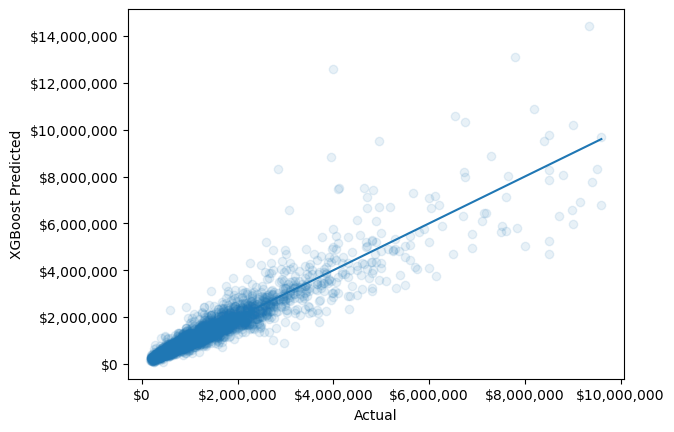

In [11]:
plt.scatter(close_test, predicted_close, alpha=0.1)
plt.plot([close_test.min(), close_test.max()],[close_test.min(), close_test.max()])
plt.xlabel("Actual")
plt.ylabel("XGBoost Predicted")
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
plt.show()

We make an interactive graph that shows the predicted and actual price along with the features that helped determined the data point prediction. By hovering over a data point, you can see its features.

In [12]:
plot_df = features_test.copy()
plot_df['PredictedPrice'] = predicted_close  # or output_test for NN
plot_df['ActualPrice'] = close_test

# Add any extra info you want to see on hover
plot_df['HoverInfo'] = (
    'YearBuilt: ' + plot_df['YearBuilt'].astype(str)+'<br>' +
    'BathroomsTotalInteger: ' + plot_df["BathroomsTotalInteger"].astype(str) + '<br>' +
    'BedroomsTotal: ' + plot_df["BedroomsTotal"].astype(str) + '<br>' +
    'GarageSpaces: ' + plot_df["GarageSpaces"].astype(str) +'<br>' +
    'Longitude: ' + plot_df["Longitude"].astype(str)+'<br>' +
    'Latitude: ' + plot_df["Latitude"].astype(str) + '<br>' +
    "PostalCodeAverage: " + plot_df["PostalCodeAverage"].astype(str) +'<br>' +
    'PostalCode: ' + testing_data['PostalCode'].astype(str) + '<br>' +
    'Living Area: ' + plot_df['LivingArea'].astype(str) + ' sqft<br>' +
    'LotSize: ' + plot_df['LotSizeAcres'].astype(str) + ' acres'
)

# Interactive scatter
fig = px.scatter(
    plot_df, 
    x='ActualPrice', 
    y='PredictedPrice', 
    hover_data=['HoverInfo'],   # show these on hover
    opacity=0.6
)

fig.update_layout(
    title='Predicted vs Actual Prices',
    xaxis_title='Actual Price',
    yaxis_title='Predicted Price'
)

fig.show()

We calculated a predicted versus residual graph, which shows that at smaller price residencies, the predictions tend to be more accurate. When the gradient boosting model predicts higher price homes, the actual price tends to be smaller leading to more negative value residuals.

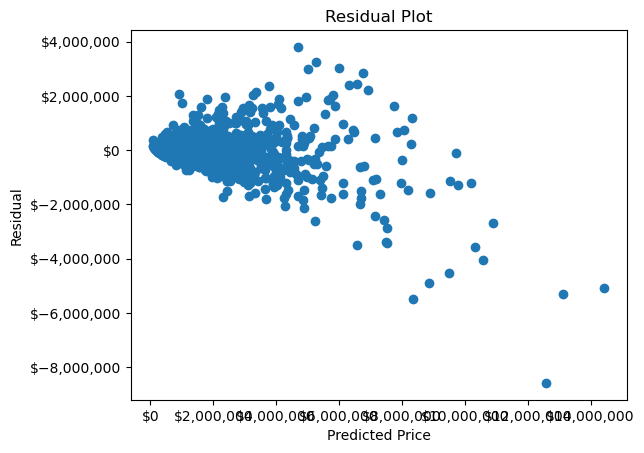

In [13]:
# Joe Hiller start
plot_df["residuals"] = plot_df['ActualPrice'] - plot_df['PredictedPrice']
plt.scatter(plot_df["PredictedPrice"], plot_df["residuals"])

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
plt.show()

#Joe Hiller end

